## Import the necessary dependencys

In [1]:
from rpgpy import rpg2nc
import numpy as np
from gfatpy.radar.rpg_nc import rpg
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from gfatpy.radar.retrieve import retrieve
from gfatpy.radar.retrieve.retrieve import retrieve_KDP, retrieve_spec_KDP, spec_to_moments
from IPython import get_ipython
from rpgpy import read_rpg
import xarray as xr

plt.close('all')
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

In [2]:
# raw_folder = "../../../radar_data/RAW/nebula_w/"
# product_folder = "../../../radar_data/PRODUCTS/nebula_w/"
raw_folder = "../../../radar_data/CLAUDIA/"
product_folder = "../../../radar_data/CLAUDIA/"

## Converting raw data to netcdf

In [17]:
date      = "2024/04/20"
file_type = "RHI.LV0"

# check if exist the folder raw folder first
if os.path.exists(raw_folder):
    raw_files = os.path.join(raw_folder, date) # folder with raw files
    print("path to raw files: ", raw_files)

    # create the same folder structure in the product folder
    date_list     = raw_files.split("/")[-3:]
    product_files = os.path.join(product_folder, *date_list)
    print("path to products files:", product_files)

    print("make product folder if it does not exist ...")
    # make the folder if it does not exist
    os.makedirs(product_files, exist_ok=True) 

    # get the list of raw files lv1
    filepaths = [os.path.join(raw_files, f) for f in os.listdir(raw_files) if f.endswith(file_type)]
    
    print("converting files to netcdf if they do not exist ...")
    # check if there are files to process or if they already exist
    if len(filepaths) == 0 or all([os.path.exists(os.path.join(product_files, f.split("/")[-1].replace(file_type, file_type + ".nc"))) for f in filepaths]):
        print("There are no files to process or they already exist")
    else:
        # converting to raw files to netcdf using rpgpy
        for f in filepaths:
            print("converting file:", f)
            rpg2nc(f, os.path.join(product_files, f.split("/")[-1].replace(file_type, file_type + ".nc")))

else:
    print("The raw folder does not exist")

path to raw files:  ../../../radar_data/RAW/nebula_w/2024/04/20
path to products files: ../../../radar_data/PRODUCTS/nebula_w/2024/04/20
make product folder if it does not exist ...
converting files to netcdf if they do not exist ...
There are no files to process or they already exist


## Reading radar files with gfatpy radar module

In [3]:
figure_folder = Path(r"../figures")
# folder_path   = Path(r"../../../radar_data/PRODUCTS/nebula_w/2024/04/20")
folder_path   = Path(r"../../../radar_data/CLAUDIA")
file_type     = "PPI.LV1.nc"

# get filepath of files ended with RHI.LV1.nc
filepaths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(file_type)]

# check if there are files to process
if len(filepaths) == 0:
    print("There are no files to process")
else:
    print("netcdf files created by rpgpy:")
    for f in filepaths:
        print(f)

    # check if filepaths is a list:
    print("\nreading the file as radar class in gfatpy...")
    if isinstance(filepaths, list):
        radar = rpg(filepaths[0])
    else:
        radar = rpg(filepaths)

netcdf files created by rpgpy:
../../../radar_data/CLAUDIA/PPI70_230708_000145_P01_PPI.LV1.nc

reading the file as radar class in gfatpy...


# LV1 quicklooks

In [ ]:
try:
    if radar.level == 1:
        radar.quicklook(
            variable=[
                "dBZe",
                "v",
                "width",
            ],
            dpi=400,
            savefig=True,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

## ZEN quicklooks

In [ ]:
try:
    if radar.level == 1 and radar.type == "ZEN":
        figs, filepath = radar.plot_zen(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            range_limits=[0, 12],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

## PPI quicklooks

/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:593: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in

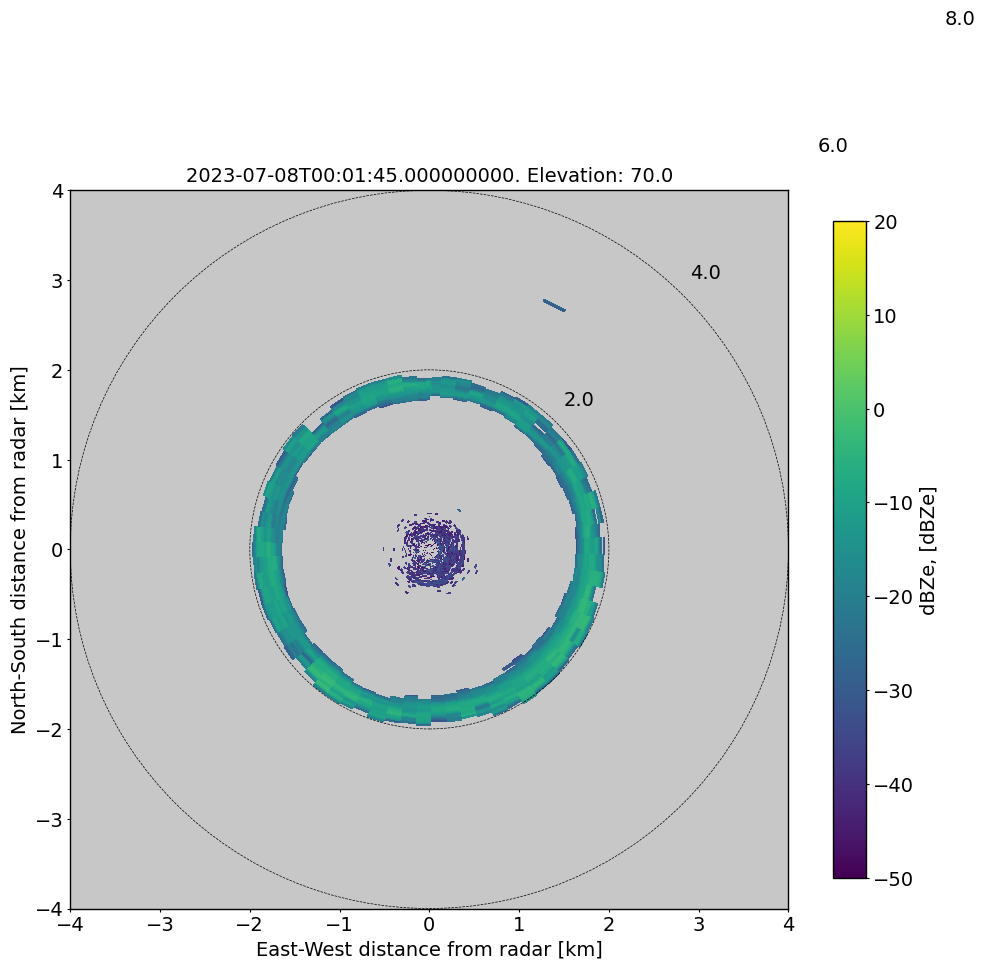

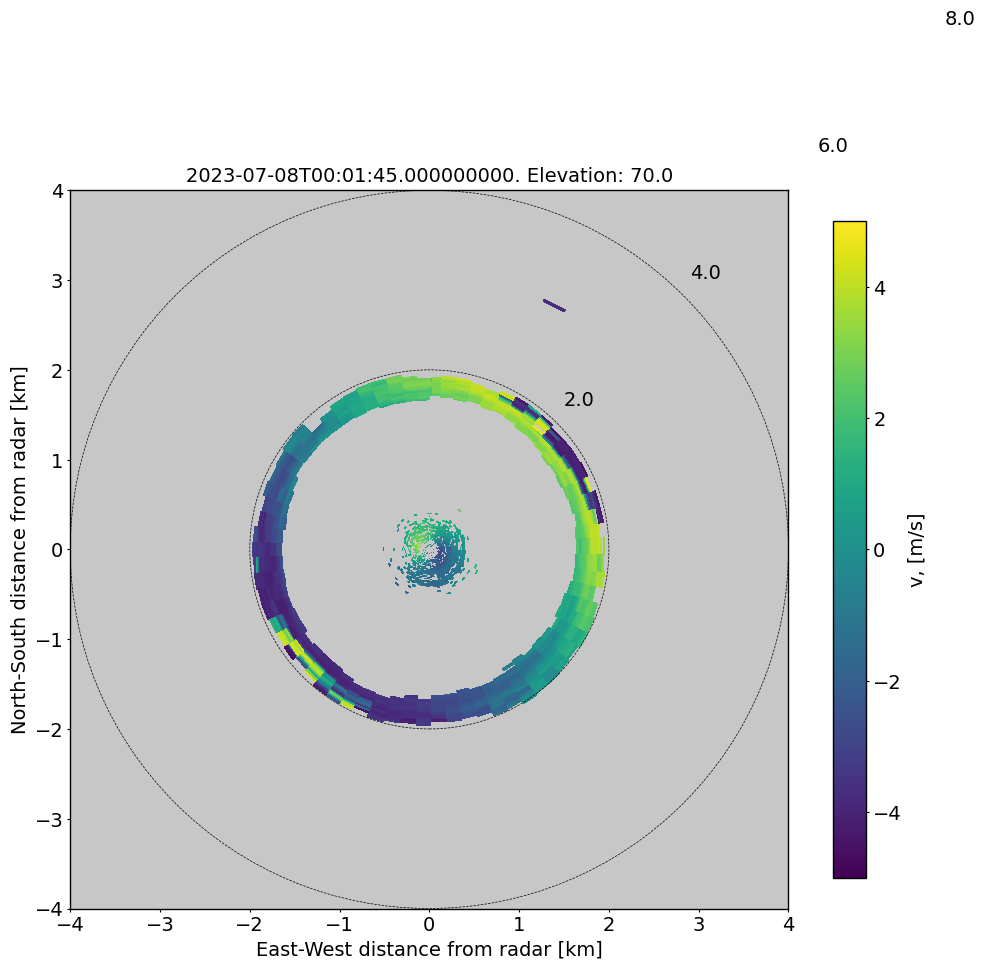

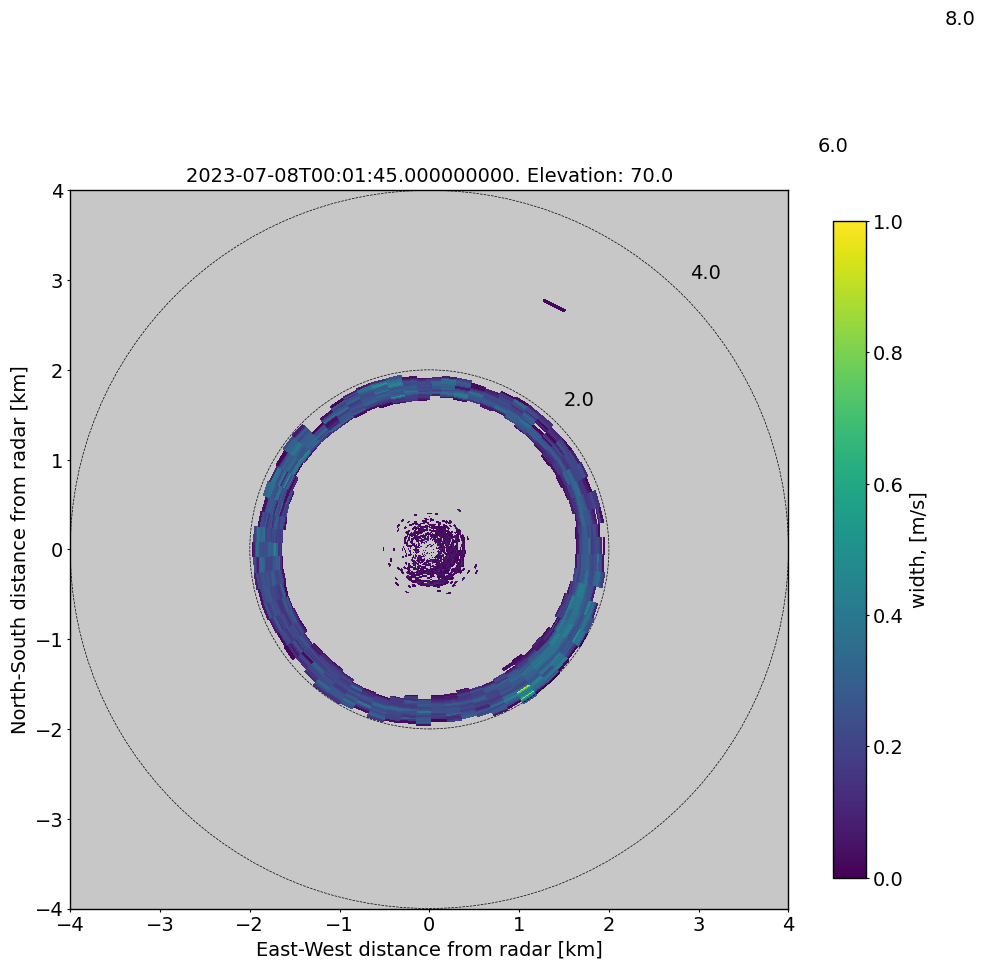

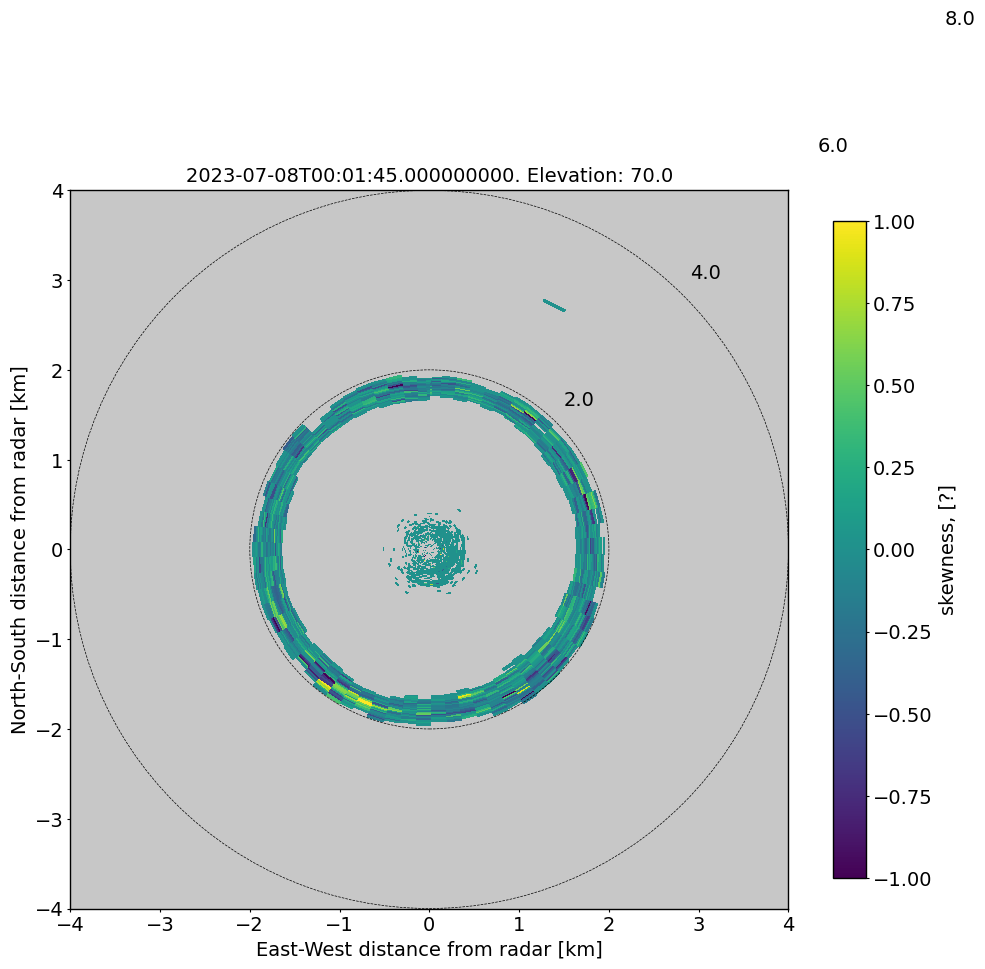

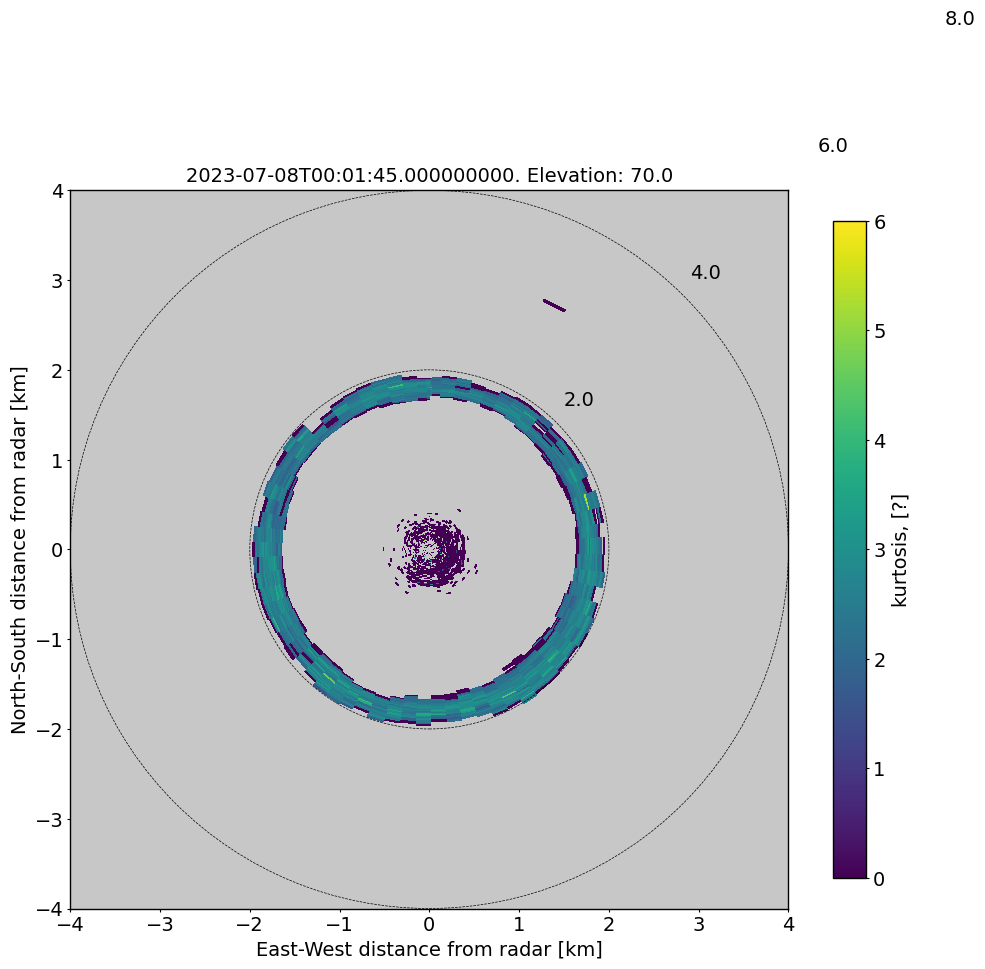

In [5]:
try:
    if radar.level == 1 and radar.type == "PPI":
        figs, filepath = radar.plot_ppi(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
        for fig in figs:
            fig.axes[0].set_xlim(-4, 4)
            fig.axes[0].set_ylim(-4, 4)
except Exception as e:
    print(e)

## RHI quicklooks

In [ ]:
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

# LV0 quicklooks

In [ ]:
try:
    targ_time = radar.data.time[10].values
    if radar.level == 0:
        fig, filepath = radar.plot_2D_spectrum(
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-40,
            vmax=40,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

In [ ]:
try:
    if radar.level == 0:
        fig, filepath = radar.plot_spectra_by_range(
            target_time= targ_time,
            range_slice=(4000, 5000),
            **{"savefig": False}
        )
except Exception as e:
    print(e)

In [ ]:
try:
    time_interval = (radar.data.time[0].values, radar.data.time[5].values)
    if radar.level == 0:
        fig, filepath = radar.plot_spectra_by_time(
            target_range= 1000,
            time_slice=time_interval,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

In [107]:
# reading binary using rpgpy 
file =   "../../tests/data/radar/RAW/2024/04/20/240420_154249_P00_ZEN.LV0"
header, binary_data = read_rpg(file)

print("printing binary data ...")
for key in binary_data:
    print(key)

printing binary data ...
Time
MSec
QF
RR
RelHum
EnvTemp
BaroP
WS
WD
DDVolt
DDTb
LWP
PowIF
Elev
Azi
Status
TransPow
TransT
RecT
PCT
TotSpec
SLv
TotNoisePow
HSpec
ReVHSpec
ImVHSpec
SLh
HNoisePow


In [118]:
print( header["SWVersion"], header["RngOffs"], header["RAltN"], header["SpecN"], binary_data["HNoisePow"] )
# analogous in rpgpy ("",chirp_start_indices, n_range_layers, n_samples_in_chirp, integrated_noise_h)

563 [ 0 20 73] 338 [512 512 512]


In [134]:
bins_per_chirp = np.diff( np.hstack((header["RngOffs"], header["RAltN"])) )
bins_per_chirp

array([ 20,  53, 265])

In [131]:
np.repeat(header["SpecN"], bins_per_chirp) # number of bins in spectrum will be always the same for each chirp?? If dont, 
                                           # we should consider the number of bins in each chirp, like this piece of code are doing                         

array([512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 51

In [129]:
binary_data["HNoisePow"] / np.repeat(header["SpecN"], bins_per_chirp)

array([[1.26307771e-06, 1.51157622e-06, 1.89279058e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.28604177e-06, 1.53208362e-06, 1.93838514e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.28846079e-06, 1.51065308e-06, 1.92092239e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [9.78413937e-07, 1.21190465e-06, 1.50966684e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00321449e-06, 1.19369918e-06, 1.46168372e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [9.84866915e-07, 1.19162473e-06, 1.43054069e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [17]:
print( HNoisePow.coords, radar_lv0.data["n_samples_in_chirp"].values, bins_per_chirp)

Coordinates:
  * time     (time) datetime64[ns] 2024-04-20T15:27:25 ... 2024-04-20T15:29:25
  * range    (range) float32 102.2 127.8 153.3 ... 1.19e+04 1.194e+04 1.197e+04 [512 512 512] [ 20  53 265]


In [23]:
np.repeat(radar_lv0.data["n_samples_in_chirp"].values, bins_per_chirp)

array([512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512,
       512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 512, 51

In [3]:
figure_folder = Path(r"../figures")
folder_path   = Path(r"../../../radar_data/PRODUCTS/2024/04/20")
file_type     = "ZEN.LV0.nc"

# get filepath of files ended with RHI.LV1.nc
filepaths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(file_type)]

# check if there are files to process
if len(filepaths) == 0:
    print("There are no files to process")
else:
    print("netcdf files created by rpgpy:")
    for f in filepaths:
        print(f)

    # check if filepaths is a list:
    print("\nreading the file as radar class in gfatpy...")
    if isinstance(filepaths, list):
        radar_lv0 = rpg(filepaths[0])
    else:
        radar_lv0 = rpg(filepaths)

netcdf files created by rpgpy:
../../../radar_data/PRODUCTS/2024/04/20/240420_154249_P00_ZEN.LV0.nc

reading the file as radar class in gfatpy...


In [6]:
radar_lv0.data.time.max()

<xarray.DataArray 'time' ()>
array('2024-04-20T15:59:48.000000000', dtype='datetime64[ns]')

In [5]:
radar_lv0.data.time.min()

<xarray.DataArray 'time' ()>
array('2024-04-20T15:42:49.000000000', dtype='datetime64[ns]')

/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value e

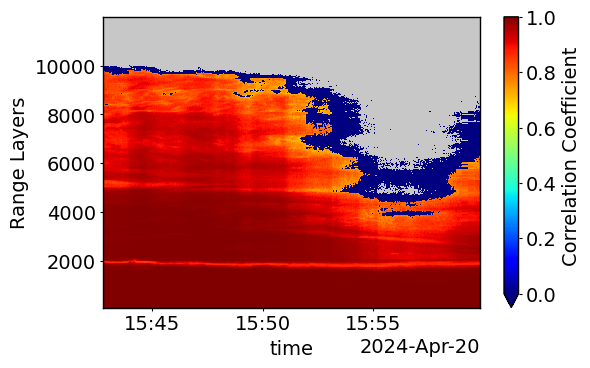

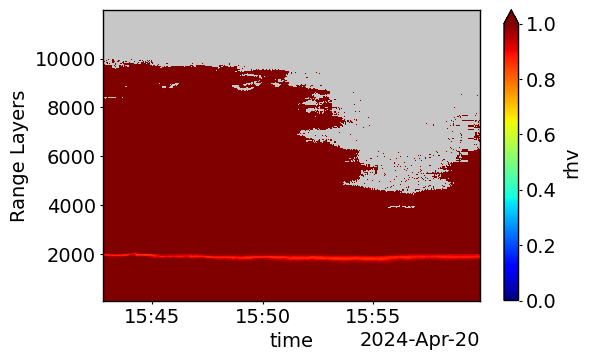

In [23]:
radar.data.correlation_coefficient.T.plot(cmap="jet", vmin=0, vmax=1)
plt.figure()
radar_lv0.data.rhv.T.plot(cmap="jet", vmin=0, vmax=1)


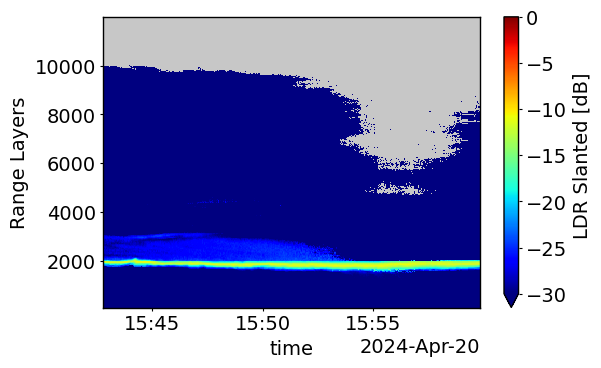

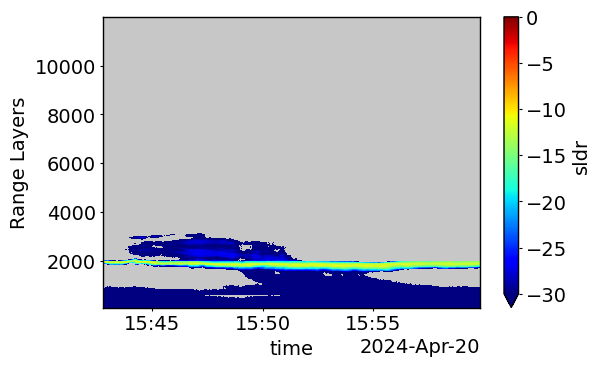

In [25]:
radar.data.ldr_slanted.T.plot(cmap="jet", vmin=-30, vmax=0)
plt.figure()
radar_lv0.data.sldr.T.plot(cmap="jet", vmin=-30, vmax=0)

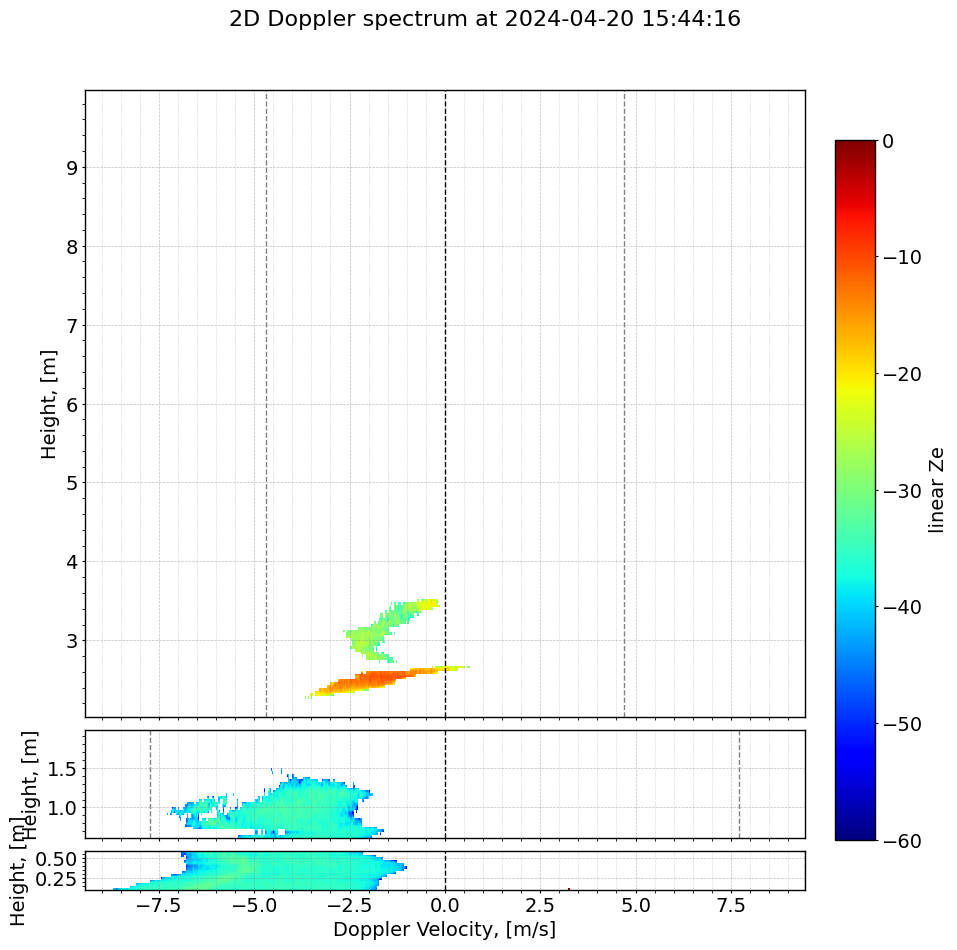

In [27]:
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_sldr",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-60,
            vmax=0,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

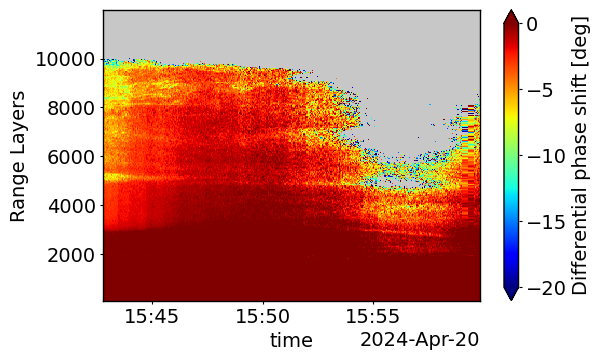

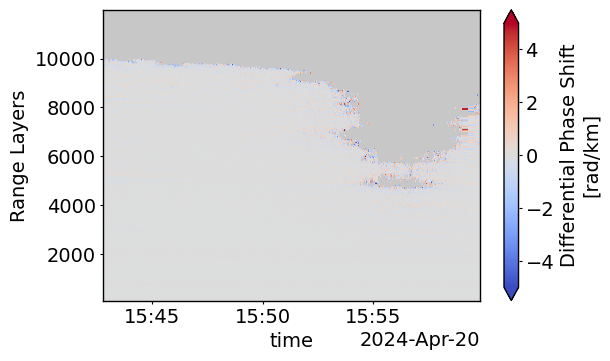

In [10]:
radar.data.differential_phase.T.plot(vmin=-20, vmax=0, cmap='jet')
plt.figure()
radar.data.differential_phase_shift.T.plot(vmin=-5, vmax=5, cmap='coolwarm')

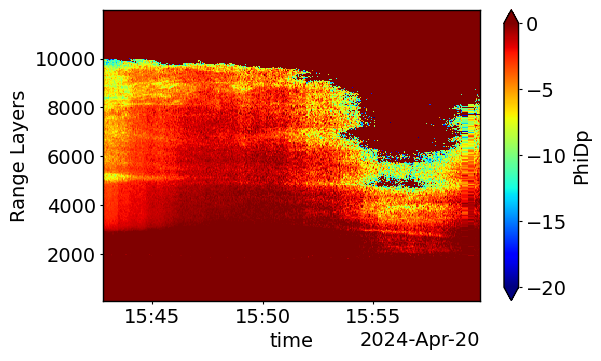

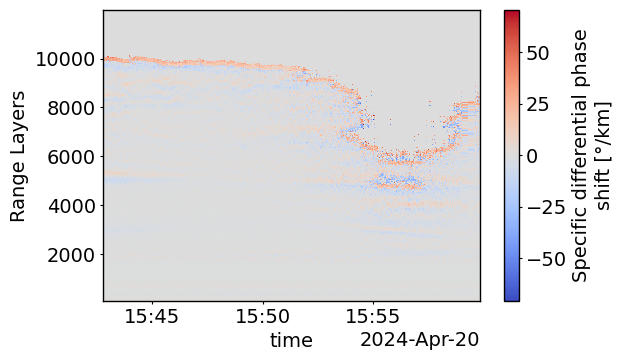

In [11]:
radar_lv0.data.PhiDp.T.plot(vmin=-20, vmax=0, cmap='jet')
plt.figure()
radar_lv0.data.KDP.T.plot(cmap='coolwarm')

In [ ]:
Ze_lv0, Vm_lv0, W_lv0, skew_lv0, kurt_lv0 = spec_to_moments(radar_lv0)

In [9]:
diff_PhiDp = radar.data.differential_phase - radar_lv0.data.PhiDp
diff_KDP = radar.data.differential_phase_shift - radar_lv0.data.KDP * (np.pi / 180) # This convertion make sense?
diff_sldr = radar.data.ldr_slanted - radar_lv0.data.sldr

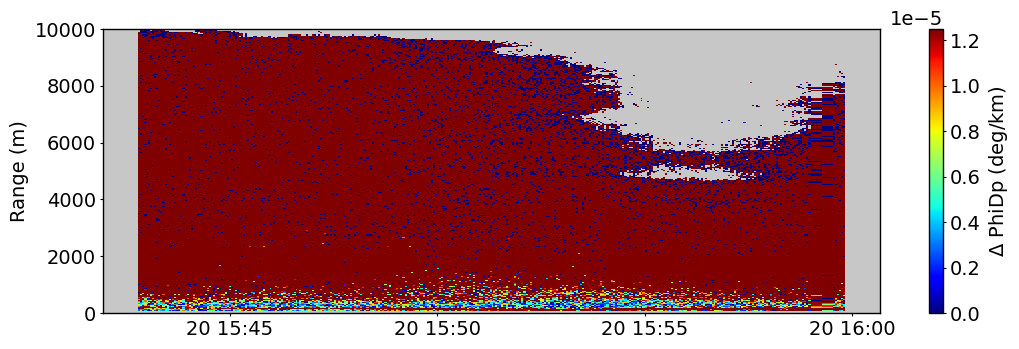

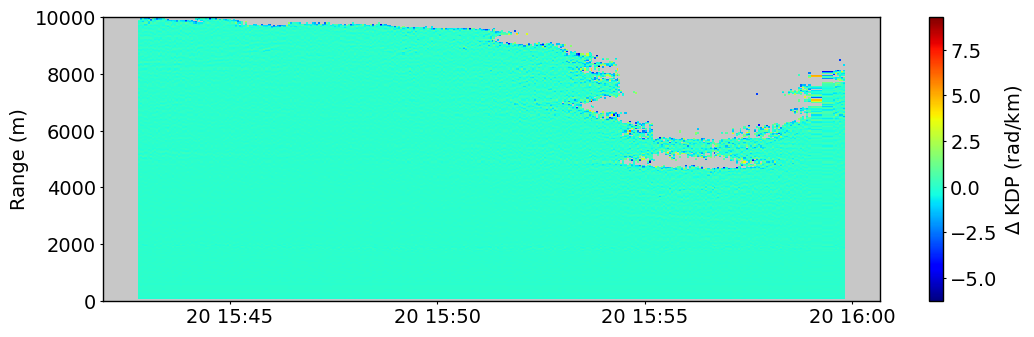

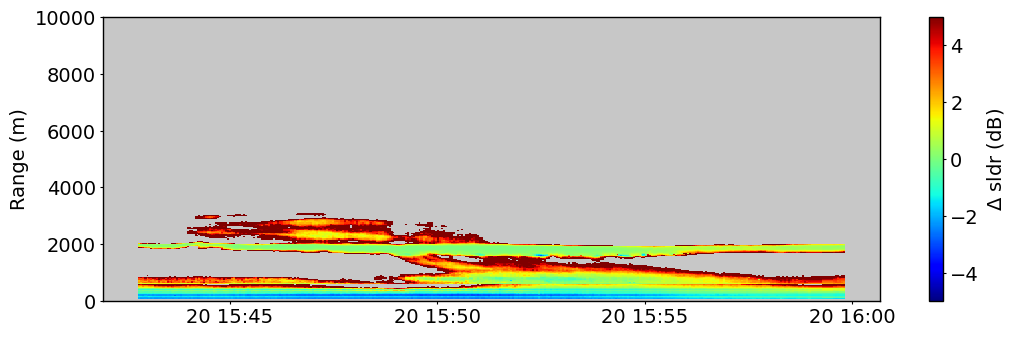

In [10]:
# Plot the difference between Phi and KDP
fig, ax = plt.subplots(figsize=(12, 4))
mesh = ax.pcolormesh(diff_PhiDp.time.values,
                      diff_PhiDp.range.values, 
                      diff_PhiDp.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=0, vmax=0.0000125)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ PhiDp (deg/km)")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
mesh = ax.pcolormesh(diff_KDP.time.values,
                      diff_KDP.range.values, 
                      diff_KDP.values.T, 
                      shading="nearest", cmap="jet",
                      )
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ KDP (rad/km)")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
mesh = ax.pcolormesh(diff_sldr.time.values,
                      diff_sldr.range.values, 
                      diff_sldr.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=-5, vmax=5)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ sldr (dB)")
plt.show()


In [53]:
diff_Ze = radar.data.Ze - Ze_lv0
diff_Vm = radar.data.v - Vm_lv0
diff_W  = radar.data.width - W_lv0
diff_skew = radar.data.skewness - skew_lv0
diff_kurt = radar.data.kurtosis - kurt_lv0
diff_zdr = radar.data.zdr - radar_lv0.data.ZDR

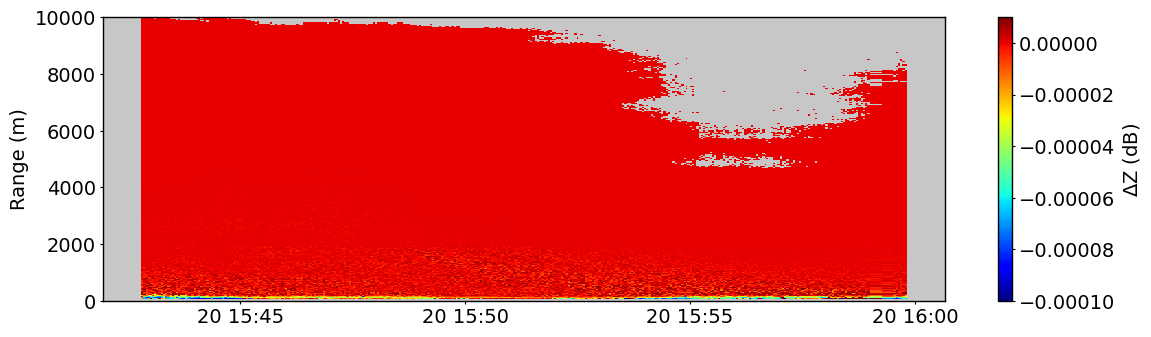

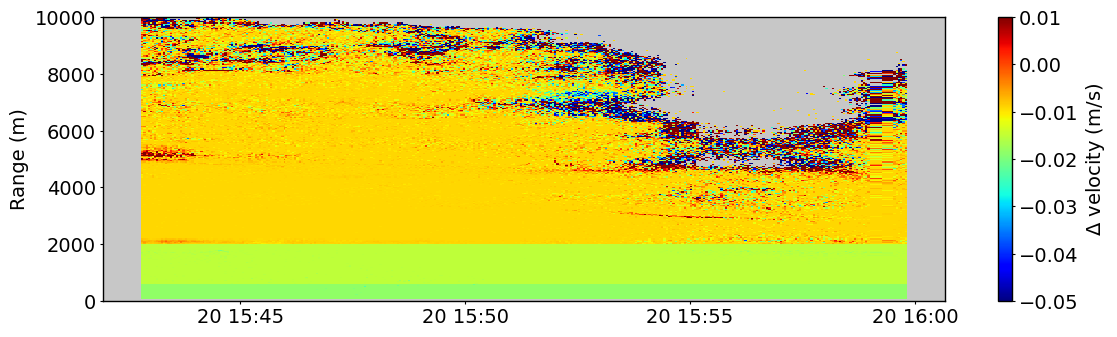

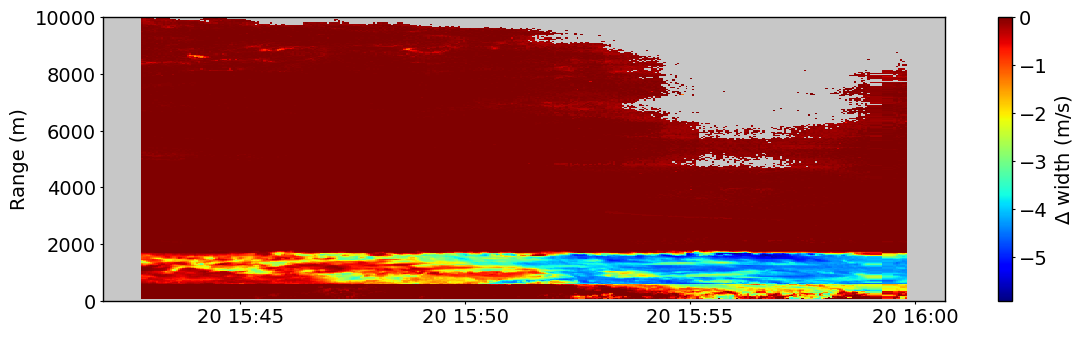

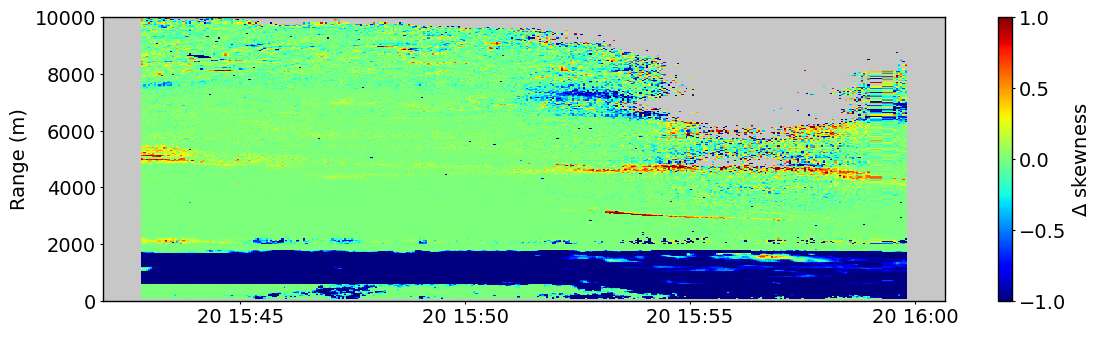

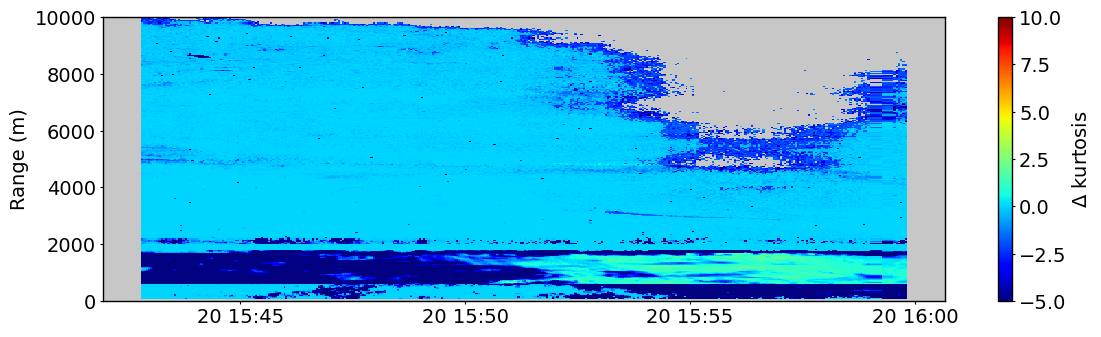

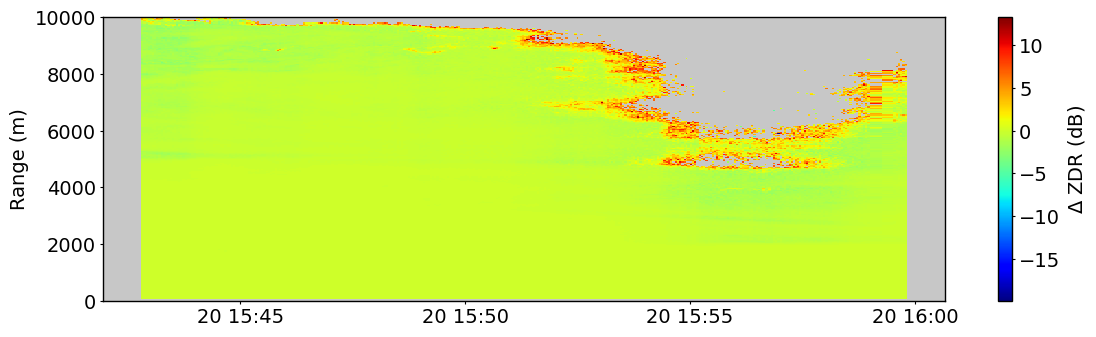

In [54]:
fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_Ze.time.values,
                      diff_Ze.range.values, 
                      diff_Ze.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=-1e-4, vmax=1e-5)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$Z (dB)")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_Vm.time.values,
                      diff_Vm.range.values, 
                      diff_Vm.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=-.05, vmax=.01)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ velocity (m/s)")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_W.time.values,
                      diff_W.range.values, 
                      diff_W.values.T, 
                      shading="nearest", cmap="jet")
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ width (m/s)")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_skew.time.values,
                      diff_skew.range.values, 
                      diff_skew.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=-1, vmax=1)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ skewness")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_kurt.time.values,
                      diff_kurt.range.values, 
                      diff_kurt.values.T, 
                      shading="nearest", cmap="jet",
                      vmin=-5, vmax=10)
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ kurtosis")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
mesh = ax.pcolormesh(diff_zdr.time.values,
                      diff_zdr.range.values, 
                      diff_zdr.values.T, 
                      shading="nearest", cmap="jet")
ax.set_ylim([0, 10000])
ax.set_ylabel("Range (m)")
plt.colorbar(mesh, label=r"$\Delta$ ZDR (dB)")
plt.show()


In [ ]:
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_spectra_by_range(
            target_time= targ_time,
            range_slice=(0, 500),
            **{"savefig": False}
        )
except Exception as e:
    print(e)

In [ ]:
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_ZDR",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-40,
            vmax=40,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

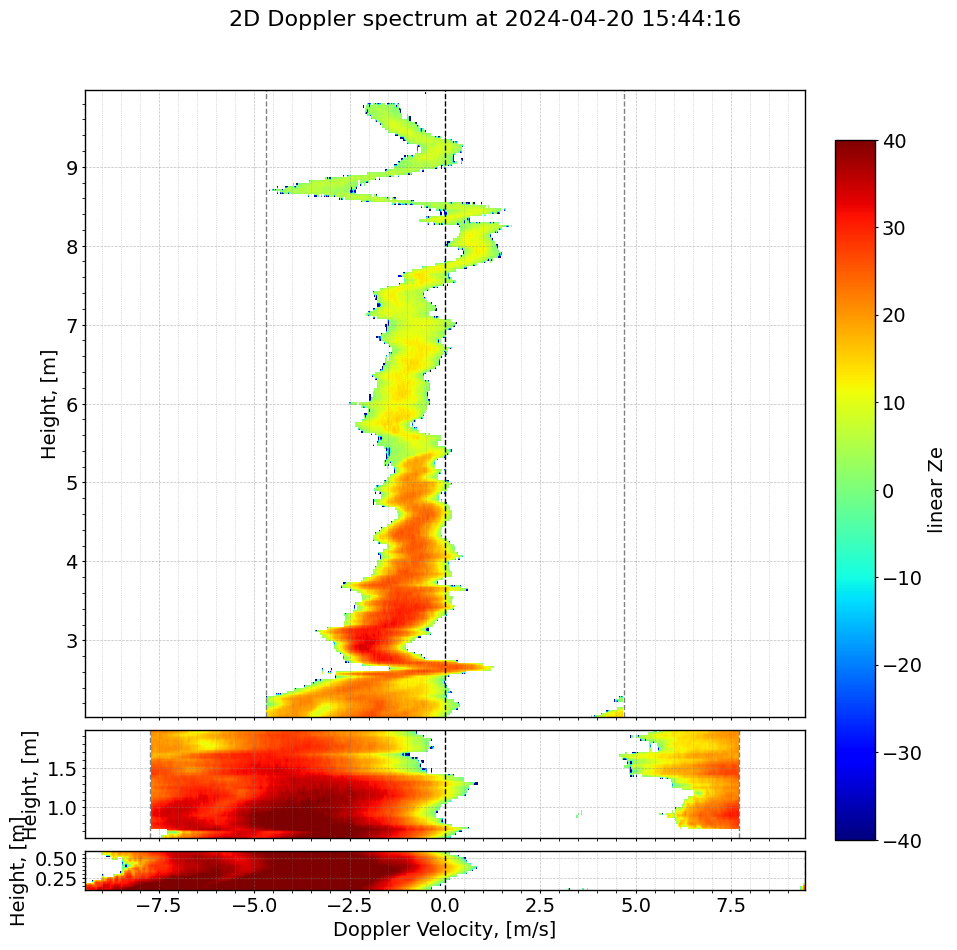

In [13]:
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="sSNR_H_dB",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-40,
            vmax=40,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

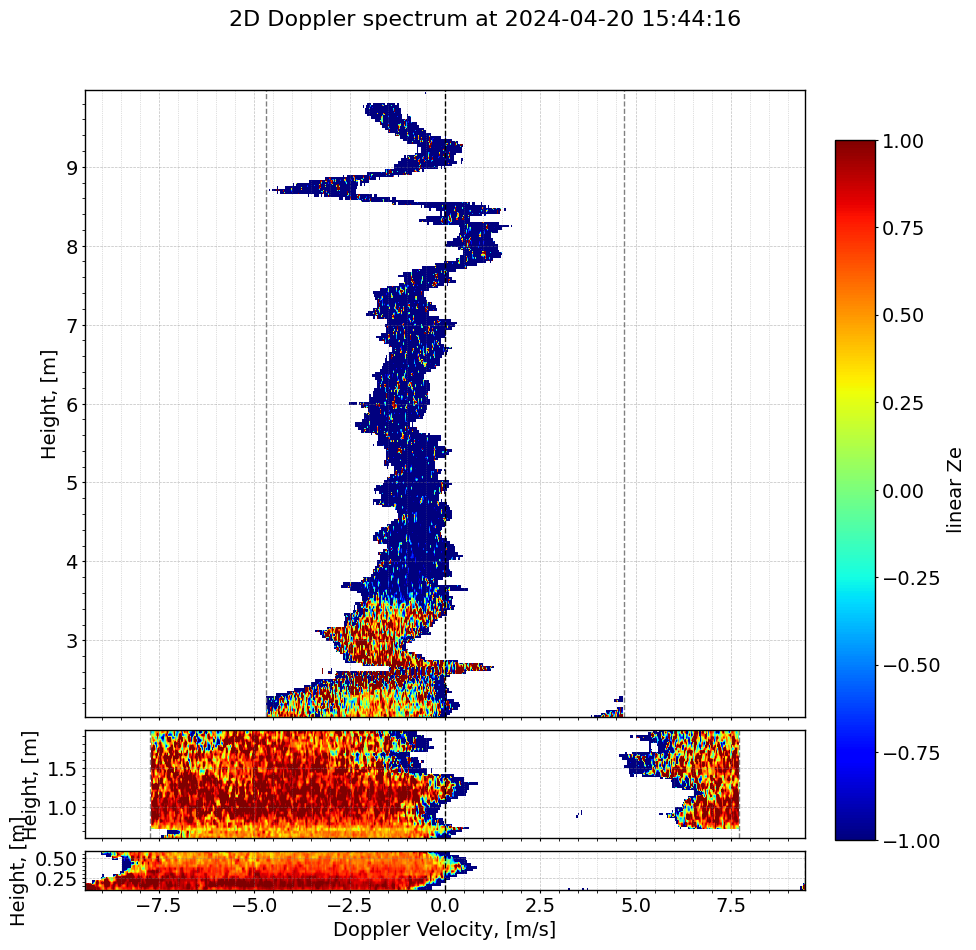

In [38]:
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_PhiDp",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-1,
            vmax=1,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

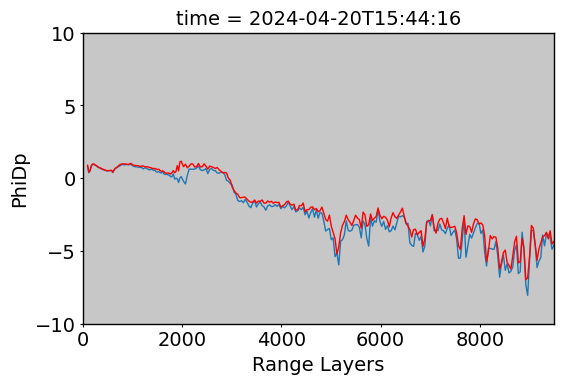

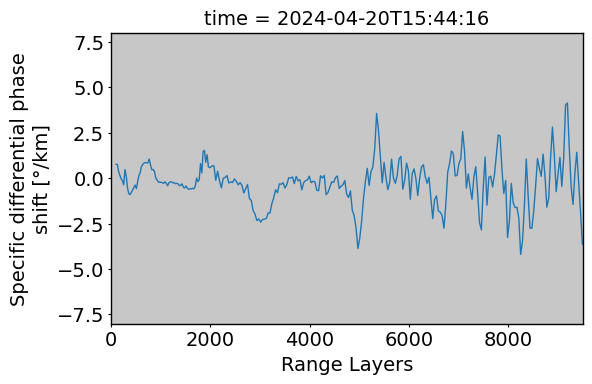

In [40]:
sdata= radar_lv0.data["spec_PhiDp"].sel(time=targ_time)
integrated_phidp = sdata.median(dim="spectrum")
integrated_phidp.plot(xlim=[0, 10000], ylim=[-10, 10])
sdata= radar_lv0.data["PhiDp"].sel(time=targ_time)
sdata.plot(xlim=[0, 9500], color="r")

KDP_profile = retrieve_KDP(radar_lv0.data["PhiDp"], (1, 10))
skdp        = KDP_profile.sel(time=targ_time)
plt.figure()
skdp.plot(xlim=[0, 9500], ylim=[-8, 8])

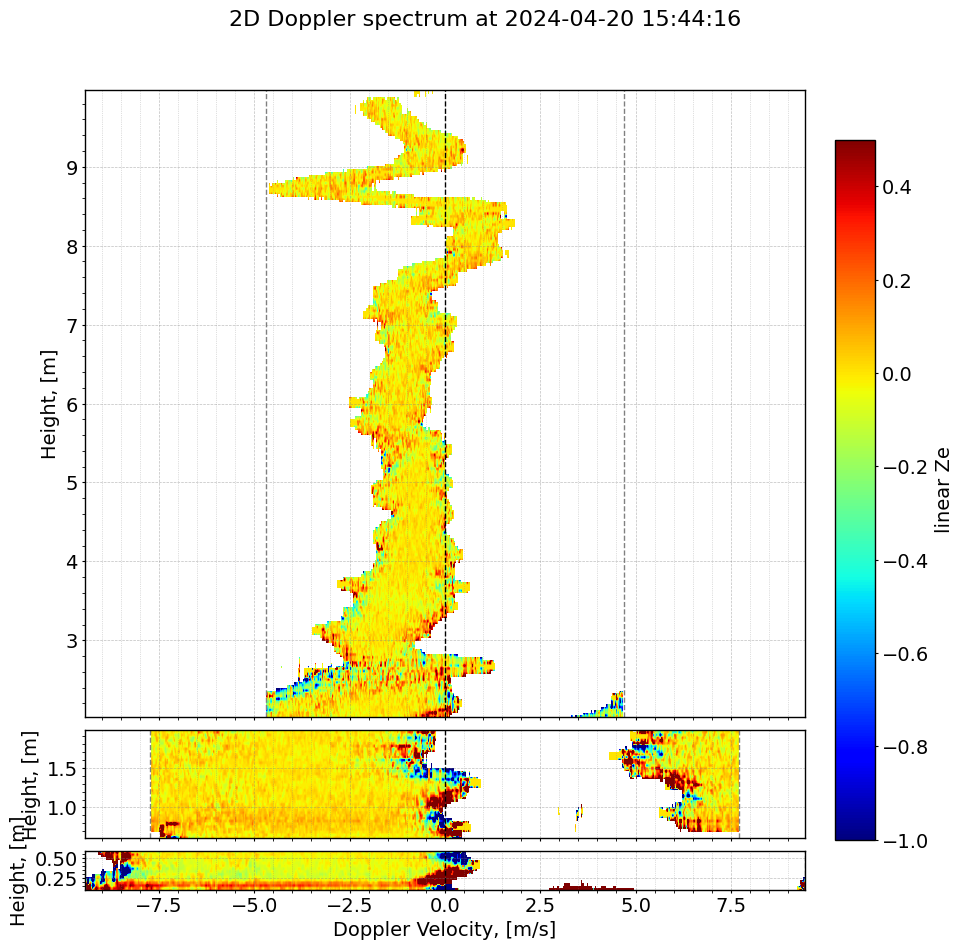

In [46]:
radar_lv0.data["spec_KDP"] = retrieve_spec_KDP(radar_lv0.data["spec_PhiDp"], (1, 5))
targ_time = radar_lv0.data.time[30].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_KDP",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-1,
            vmax=.5,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

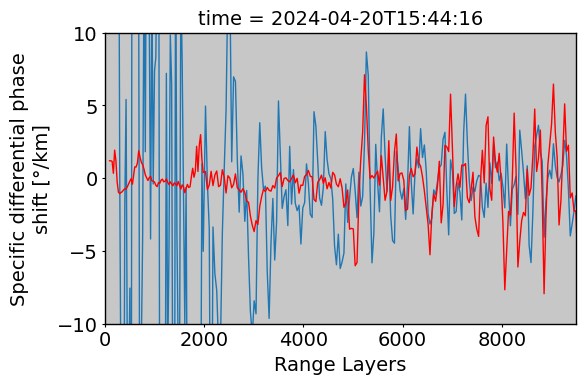

In [47]:
radar_lv0.data["spec_KDP"] = retrieve_spec_KDP(radar_lv0.data["spec_PhiDp"], (1, 5))
sdata = radar_lv0.data["spec_KDP"].sel(time=targ_time).sum(dim="spectrum")

sdata.plot(xlim=[0, 9500], ylim=[-10, 10])
sdata= radar_lv0.data["KDP"].sel(time=targ_time)
sdata.plot(xlim=[0, 9500], color="r")

In [ ]:
# 1) remove this small peaks to see what happens 
# 2) calculate the moments and see the diference 
# 3) remove the diferences and see the difference in the 

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:659: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasi

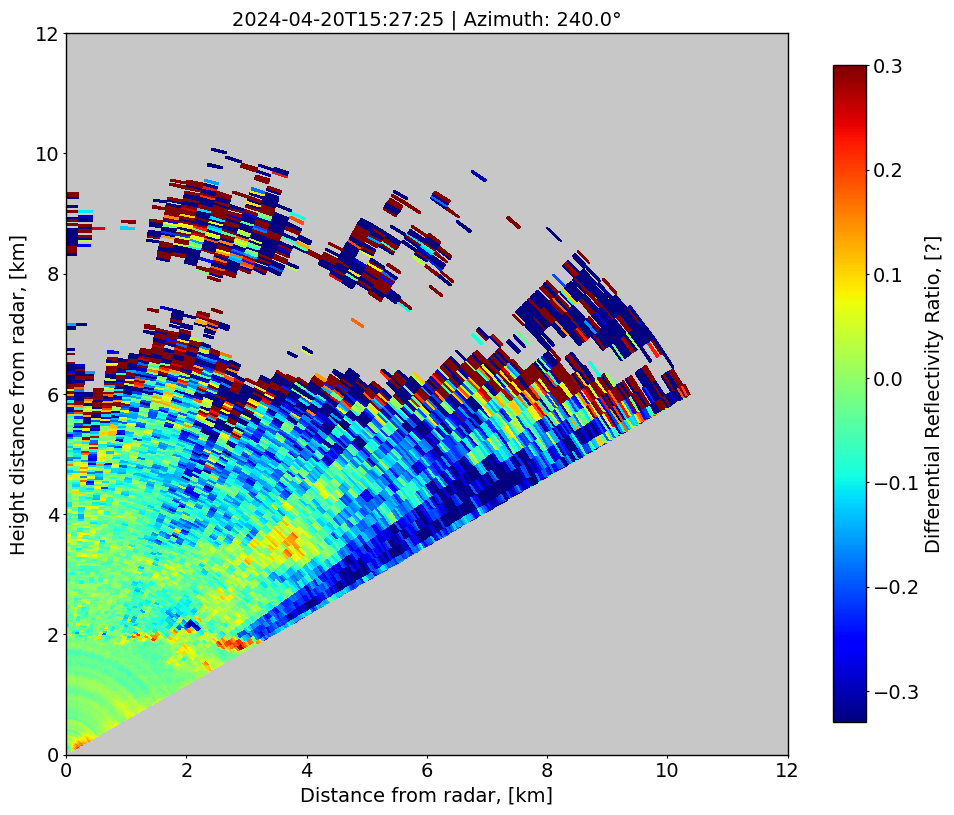

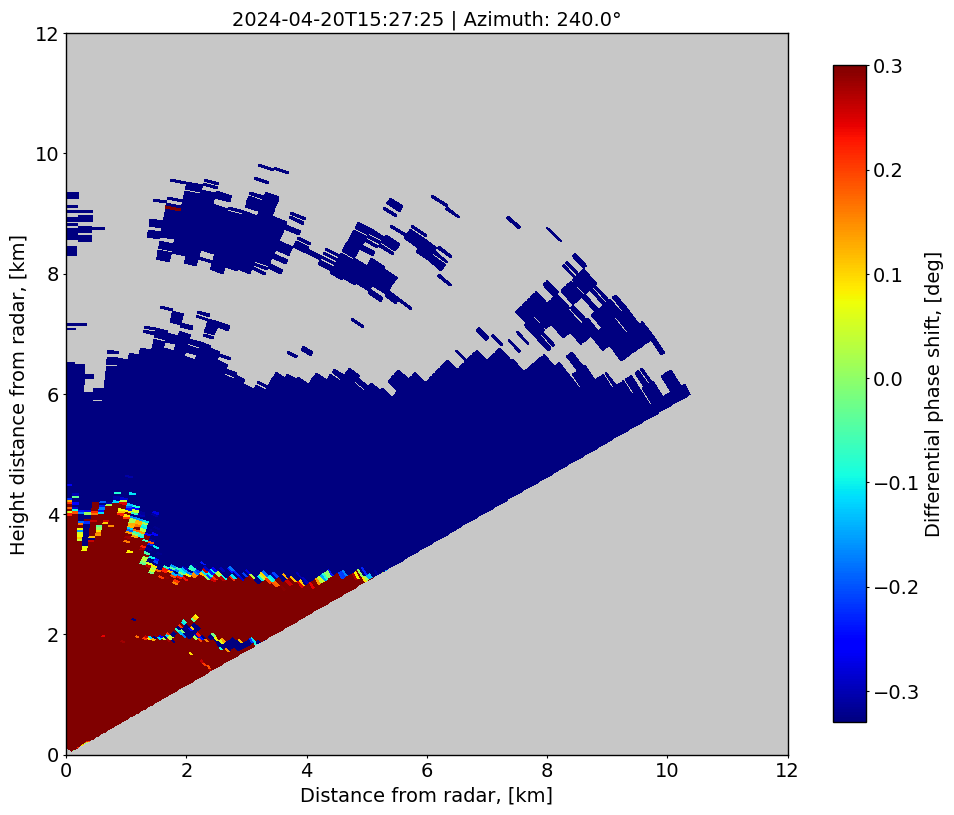

In [71]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "zdr",
                "differential_phase",
            ],
            dpi=400,
            vmin=-.3,
            vmax=.3,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:659: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


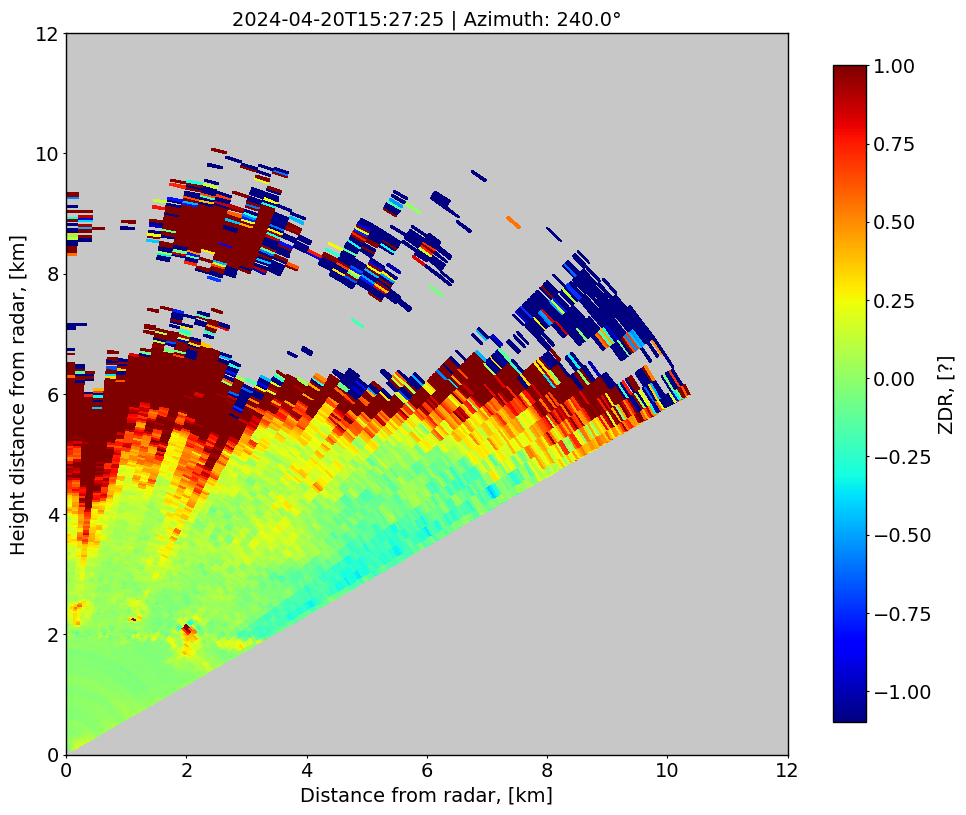

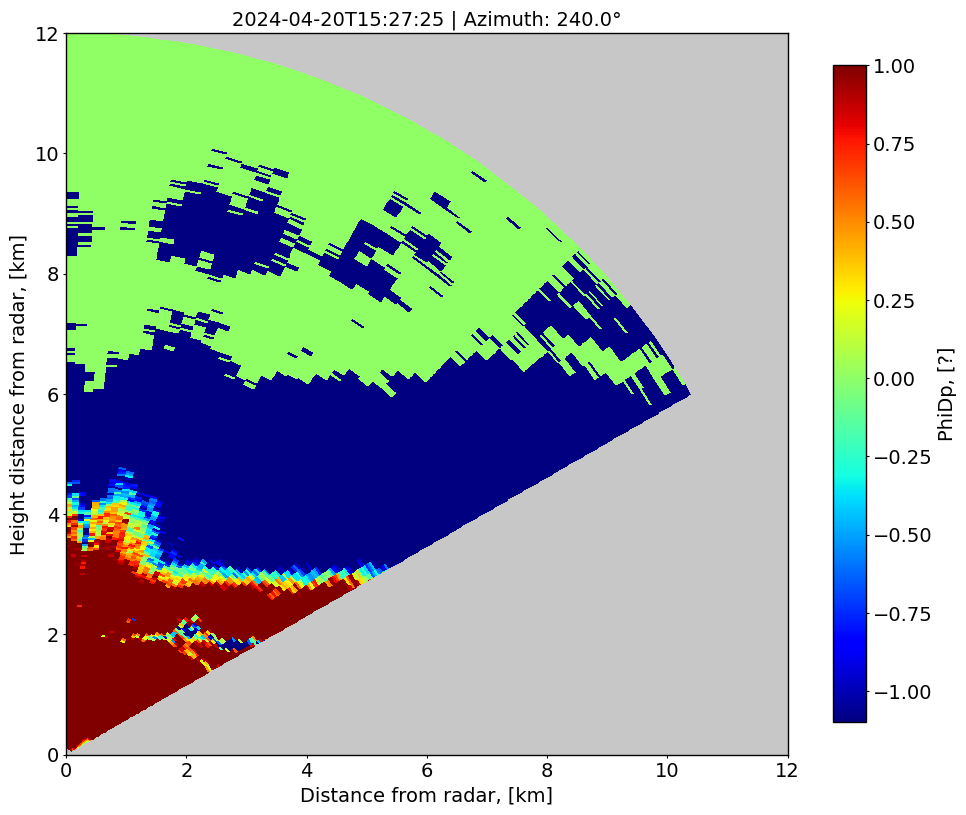

In [72]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar_lv0.level == 0 and radar.type == "RHI":
        figs, filepath = radar_lv0.plot_rhi(
            variable=[
                "ZDR",
                "PhiDp",
            ],
            dpi=400,
            vmin=-1,
            vmax=1,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:659: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasi

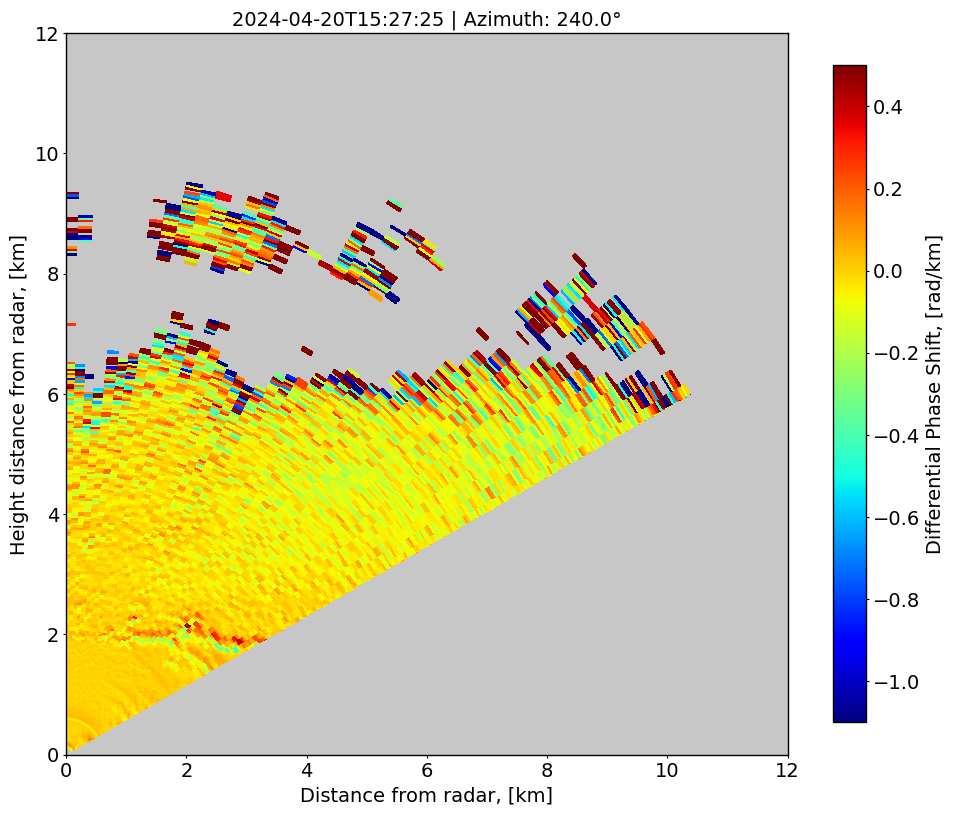

In [27]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "differential_phase_shift",
            ],
            dpi=400,
            vmin=-1,
            vmax=.5,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:659: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


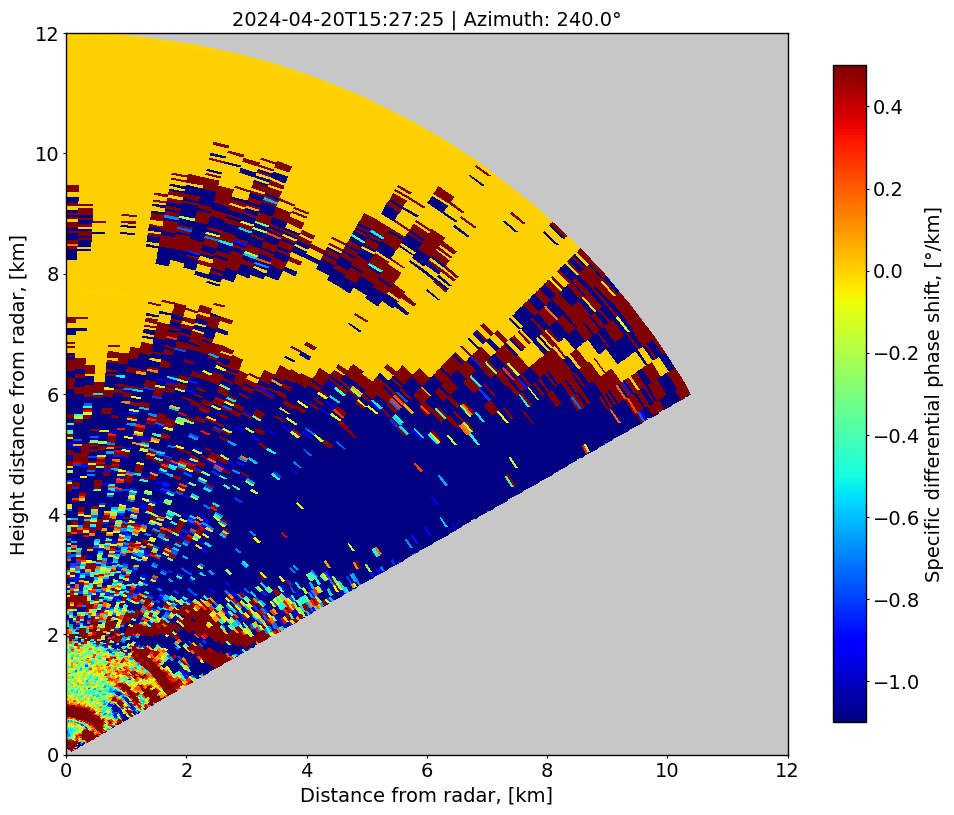

In [73]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar_lv0.level == 0 and radar.type == "RHI":
        figs, filepath = radar_lv0.plot_rhi(
            variable=[
                "KDP",
            ],
            dpi=400,
            vmin=-1,
            vmax=.5,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

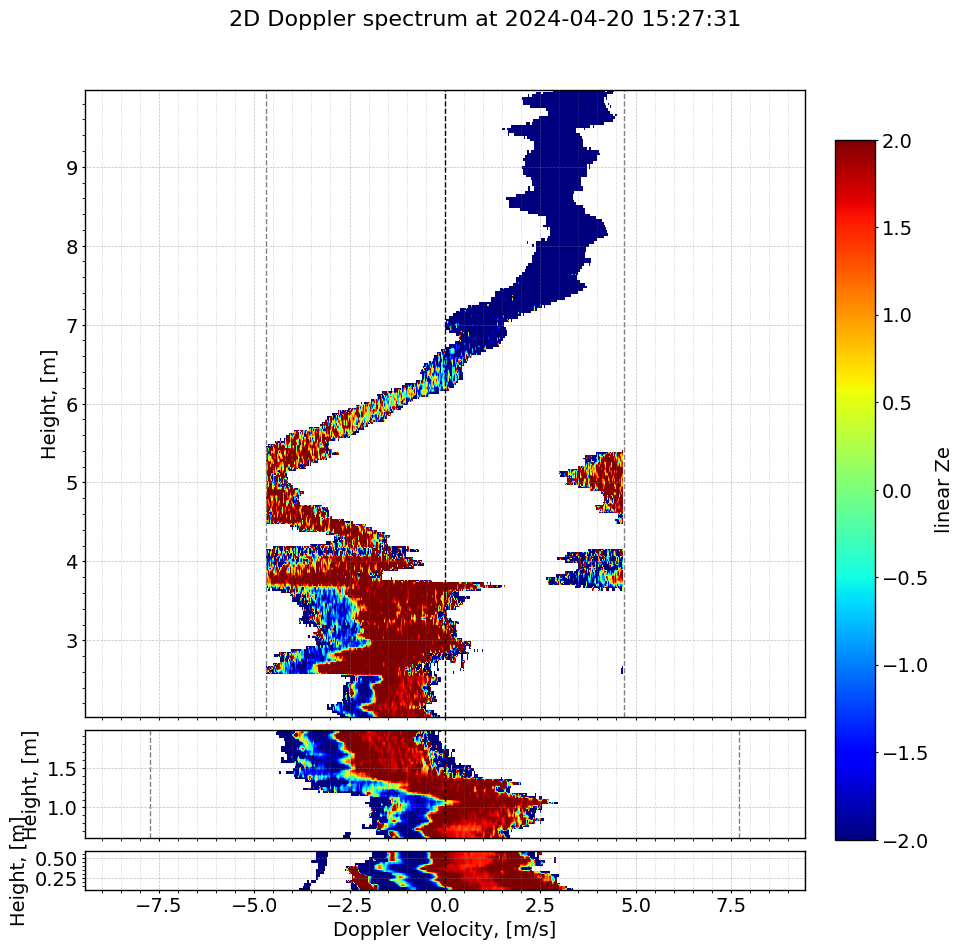

In [74]:
targ_time = radar_lv0.data.time[2].values
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_PhiDp",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-2,
            vmax=2,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

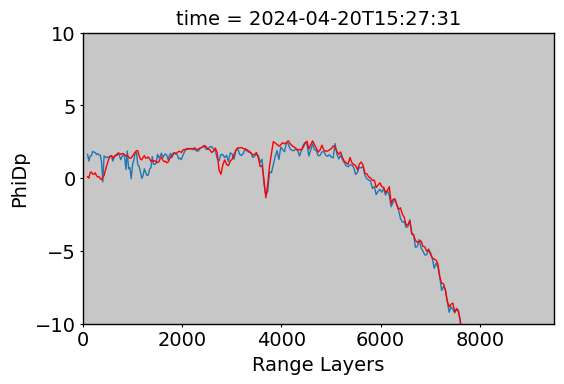

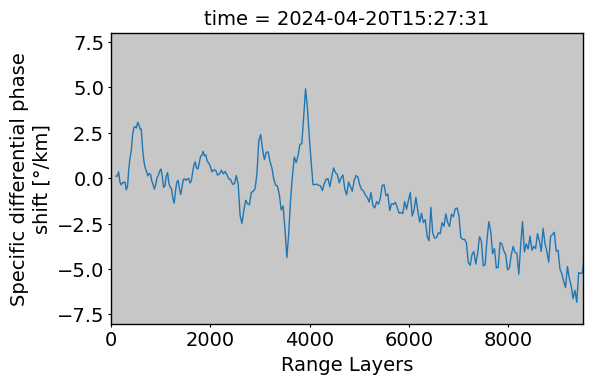

In [40]:
sdata= radar_lv0.data["spec_PhiDp"].sel(time=targ_time)
integrated_phidp = sdata.median(dim="spectrum")
integrated_phidp.plot(xlim=[0, 10000], ylim=[-10, 10])
sdata= radar_lv0.data["PhiDp"].sel(time=targ_time)
sdata.plot(xlim=[0, 9500], color="r")

KDP_profile = retrieve_KDP(radar_lv0.data["PhiDp"], (1, 10))
skdp        = KDP_profile.sel(time=targ_time)
plt.figure()
skdp.plot(xlim=[0, 9500], ylim=[-8, 8])

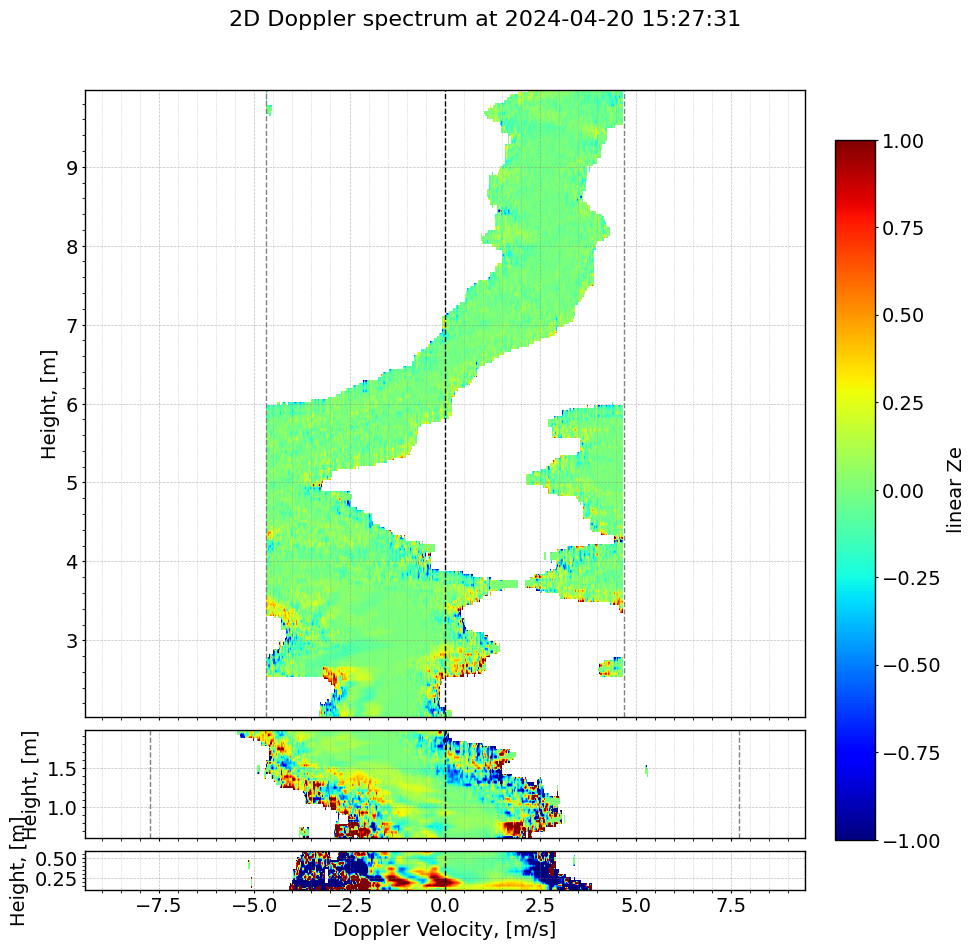

In [81]:
radar_lv0.data["spec_KDP"] = retrieve_spec_KDP(radar_lv0.data["spec_PhiDp"], (5, 5))
try:
    if radar_lv0.level == 0:
        fig, filepath = radar_lv0.plot_2D_spectrum(
            variable="spec_KDP",
            target_time= targ_time,
            range_limits=[0, 10000],
            vmin=-1,
            vmax=1,
            **{"savefig": False}
        )
except Exception as e:
    print(e)

In [104]:
radar_lv0.data

<xarray.Dataset>
Dimensions:                         (range: 338, chirp: 3, spectrum: 512,
                                     time: 42)
Coordinates:
  * time                            (time) datetime64[ns] 2024-04-20T15:27:25...
  * range                           (range) float32 102.2 127.8 ... 1.197e+04
  * chirp                           (chirp) int64 0 1 2
Dimensions without coordinates: spectrum
Data variables: (12/96)
    file_code                       int32 ...
    header_length                   int32 ...
    program_number                  int32 ...
    model_number                    int32 ...
    radar_frequency                 float32 ...
    antenna_separation              float32 ...
    ...                              ...
    sSNR_V_dB                       (time, range, spectrum) float32 nan ... nan
    ZH                              (time, range) float32 10.23 12.34 ... 0.0
    ZV                              (time, range) float32 9.902 12.04 ... 0.0
    spec_ZDR                        (time, range, spectrum) float32 nan ... nan
    ZDP                             (time, range) float32 1.033 1.025 ... nan
    ZDR                             (time, range) float32 0.1416 0.1077 ... nan
Attributes:
    Conventions:       CF-1.7
    year:              2024
    month:             04
    day:               20
    uuid:              718763f1ba9b4f23b14349d7eae49f4a
    rpgpy_version:     0.15.8
    rpg_file_version:  3.5
    history:           Radar file created: 2024-08-02 10:37:41
    level:             0

In [94]:
radar.data.ldr_slanted.values

array([[-29.904644, -30.37732 , -30.343946, ..., -11.676002, -11.071612,
         -9.766318],
       [-29.817064, -30.606739, -30.542484, ..., -16.17611 , -10.63467 ,
        -11.240963],
       [-29.815052, -30.520933, -30.44857 , ...,  -9.154835,  -9.380244,
         -9.595874],
       ...,
       [-32.783794, -34.450863, -34.390717, ...,        nan,        nan,
               nan],
       [-35.715416, -36.984875, -37.27188 , ...,        nan,        nan,
               nan],
       [-35.53501 , -36.888214, -37.095177, ...,        nan,        nan,
               nan]], dtype=float32)